# Assignment 3 — Training Neural Networks on MNIST
**DSA 8401 · Applied Machine Learning · MSc Data Science & Analytics**

---

## How to read this notebook
Every section follows the same four-question loop:

> *What did I change? → What happened? → Why did it happen? → What did I learn?*

Work through the tasks in order. The test set is **never** used until Task 7.

---
## Task 0 — Setup & Reproducibility

**Why this matters:**
- Setting a **random seed** locks every source of randomness (weight init, data shuffling), so your results can be reproduced exactly.
- Printing **library versions** lets anyone recreate your environment in the future.
- Importing everything upfront keeps later cells focused on ideas, not imports.

In [33]:
# ── Imports ───────────────────────────────────────────────────────────────────
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix, classification_report

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)           # NumPy random ops
tf.random.set_seed(SEED)       # TensorFlow / Keras random ops
os.environ['PYTHONHASHSEED'] = str(SEED)  # Python hash randomisation

# ── Library versions (for reproducibility reporting) ─────────────────────────
print(f"NumPy      : {np.__version__}")
print(f"TensorFlow : {tf.__version__}")
print(f"Keras      : {keras.__version__}")
print(f"\nGPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

NumPy      : 1.26.4
TensorFlow : 2.16.1


AttributeError: module 'tensorflow.keras' has no attribute '__version__'

---
## Task 1 — Data Preparation

### What is MNIST?
- **70,000 grayscale images** of handwritten digits (0–9), each **28 × 28 pixels**.
- 60,000 for training, 10,000 held out for testing.
- Each pixel is an integer in `[0, 255]` representing brightness.

### Steps we follow
1. **Load** the raw binary files.
2. **Inspect** shapes and class counts.
3. **Visualise** a sample grid.
4. **Scale** pixels to `[0, 1]`.
5. **Flatten** images to 784-d vectors (for MLPs).
6. **Split off** a validation set — model selection only touches this, never the test set.

### 1a · Load & inspect shapes

In [24]:
# ── Load MNIST ────────────────────────────────────────────────────────────────
# keras.datasets.mnist reads the same binary format as our local files.
# If you prefer local files, swap this line for the idx parser below.
(X_raw_train, y_raw_train), (X_test_raw, y_test_raw) = keras.datasets.mnist.load_data()

# ── Sanity check ──────────────────────────────────────────────────────────────
print("Training images :", X_raw_train.shape)   # (60000, 28, 28)
print("Training labels :", y_raw_train.shape)   # (60000,)
print("Test images     :", X_test_raw.shape)    # (10000, 28, 28)
print("Test labels     :", y_test_raw.shape)    # (10000,)
print("\nPixel range — min:", X_raw_train.min(), "max:", X_raw_train.max())
print("Label values     :", np.unique(y_raw_train))  # 0..9

Training images : (60000, 28, 28)
Training labels : (60000,)
Test images     : (10000, 28, 28)
Test labels     : (10000,)

Pixel range — min: 0 max: 255
Label values     : [0 1 2 3 4 5 6 7 8 9]


### 1b · Visualise — sample grid & class distribution

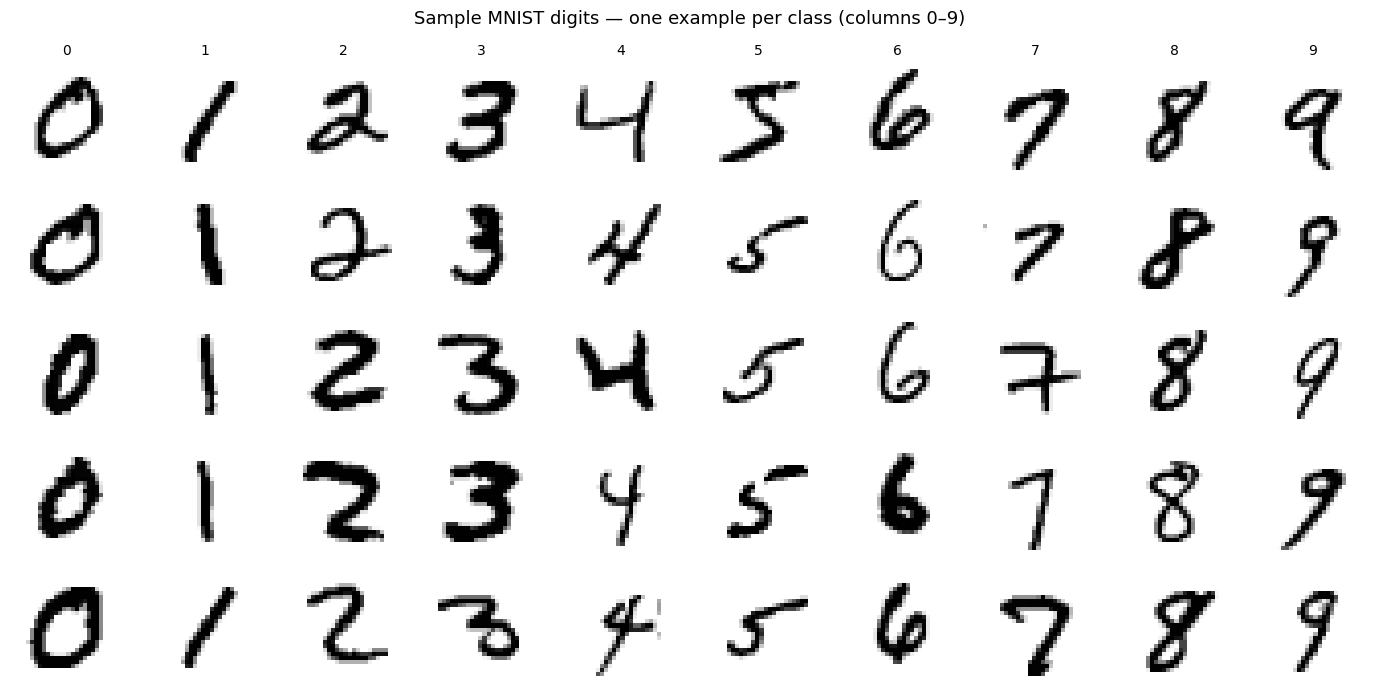

In [25]:
# ── Sample digit grid (5 rows × 10 cols, one per class) ──────────────────────
fig, axes = plt.subplots(5, 10, figsize=(14, 7))
fig.suptitle("Sample MNIST digits — one example per class (columns 0–9)", fontsize=13)

for col in range(10):                           # one column per digit class
    idx = np.where(y_raw_train == col)[0][:5]   # first 5 examples of that digit
    for row, i in enumerate(idx):
        ax = axes[row, col]
        ax.imshow(X_raw_train[i], cmap='gray_r')  # gray_r = dark digit, white bg
        ax.axis('off')
        if row == 0:
            ax.set_title(str(col), fontsize=10)

plt.tight_layout()
plt.show()

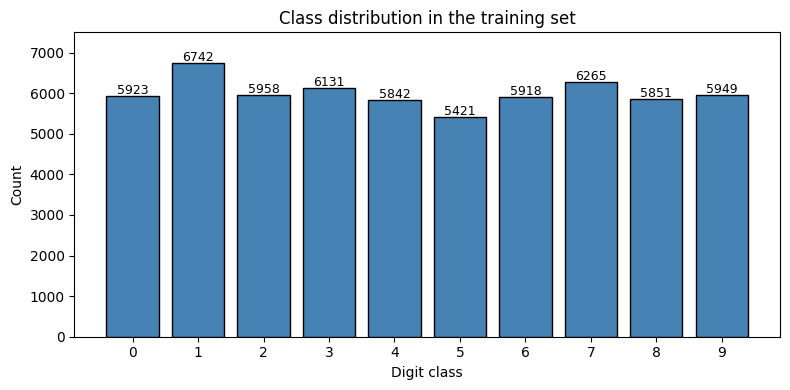

Min count: 5421  Max count: 6742
→ The dataset is well-balanced. Accuracy is a fair metric here.


In [26]:
# ── Class distribution ────────────────────────────────────────────────────────
# We want ~6,000 examples per class. Imbalanced classes would skew accuracy.
unique, counts = np.unique(y_raw_train, return_counts=True)

plt.figure(figsize=(8, 4))
plt.bar(unique, counts, color='steelblue', edgecolor='black')
plt.xticks(unique)
plt.xlabel('Digit class')
plt.ylabel('Count')
plt.title('Class distribution in the training set')
plt.ylim(0, 7500)
for x, c in zip(unique, counts):
    plt.text(x, c + 50, str(c), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print("Min count:", counts.min(), " Max count:", counts.max())
print("→ The dataset is well-balanced. Accuracy is a fair metric here.")

### 1c · Scale pixels to [0, 1]

**Why we scale:**
- Raw pixel values reach 255. Without scaling, the first layer receives large inputs → large pre-activations → sigmoid/tanh saturates immediately → gradients vanish before learning starts.
- After dividing by 255 every input is in `[0, 1]`, keeping activations in the gradient-friendly region of every activation function.
- This is the simplest form of **feature normalisation** — one of the most impactful one-line changes in deep learning.

In [27]:
# ── Scale to [0, 1] (float32 uses less memory than float64) ──────────────────
X_raw_train = X_raw_train.astype('float32') / 255.0
X_test_raw  = X_test_raw.astype('float32')  / 255.0

print("After scaling — min:", X_raw_train.min(), " max:", X_raw_train.max())

After scaling — min: 0.0  max: 1.0


### 1d · Validation split & flattening

**Three data roles — never mix them:**
| Split | Size | Role |
|---|---|---|
| `X_train` | 55,000 | Gradient updates (model sees these) |
| `X_val` | 5,000 | Hyperparameter tuning (model does NOT learn from these) |
| `X_test` | 10,000 | Final one-time evaluation (touched only in Task 7) |

**Flattening:**
- A fully-connected Dense layer expects a 1-D vector per sample.
- We reshape `(28, 28)` → `(784,)` — every pixel becomes one input feature.
- We also keep the original `(28, 28, 1)` tensors for the CNN in Task 8.

In [28]:
# ── Validation split (last 5,000 of the 60,000 training examples) ─────────────
VAL_SIZE = 5000
X_val_2d   = X_raw_train[-VAL_SIZE:]        # keep 2-D shape for CNN (Task 8)
y_val      = y_raw_train[-VAL_SIZE:]
X_tr_2d    = X_raw_train[:-VAL_SIZE]
y_train    = y_raw_train[:-VAL_SIZE]

X_test_2d  = X_test_raw                     # 2-D version kept for Task 8
y_test     = y_test_raw

# ── Flatten: (N, 28, 28) → (N, 784) for Dense layers ─────────────────────────
X_train = X_tr_2d.reshape(-1, 784)          # -1 means 'infer this dimension'
X_val   = X_val_2d.reshape(-1, 784)
X_test  = X_test_2d.reshape(-1, 784)

# ── Also add channel dim for CNN: (N, 28, 28) → (N, 28, 28, 1) ───────────────
X_train_cnn = X_tr_2d[..., np.newaxis]      # will be used in Task 8 only
X_val_cnn   = X_val_2d[..., np.newaxis]
X_test_cnn  = X_test_2d[..., np.newaxis]

# ── Final shapes summary ──────────────────────────────────────────────────────
print("MLP inputs  (flat vectors)")
print(f"  X_train : {X_train.shape}  y_train : {y_train.shape}")
print(f"  X_val   : {X_val.shape}   y_val   : {y_val.shape}")
print(f"  X_test  : {X_test.shape}  y_test  : {y_test.shape}")
print("\nCNN inputs  (2-D tensors, for Task 8)")
print(f"  X_train_cnn : {X_train_cnn.shape}")

MLP inputs  (flat vectors)
  X_train : (55000, 784)  y_train : (55000,)
  X_val   : (5000, 784)   y_val   : (5000,)
  X_test  : (10000, 784)  y_test  : (10000,)

CNN inputs  (2-D tensors, for Task 8)
  X_train_cnn : (55000, 28, 28, 1)


### Task 1 — What we learned

- MNIST is **well-balanced** — each digit has ~5,900–6,700 training examples, so plain accuracy is a reliable metric.
- **Scaling to [0, 1]** is not optional for gradient-based training — it keeps every activation function in its sensitive (non-saturated) region.
- **Flattening destroys spatial structure** — pixels that are neighbours in the image become unrelated inputs to the Dense layer. This is the core weakness of MLPs on images; we will measure it directly in Task 8.
- The **three-split discipline** (train / val / test) is the single most important habit in applied ML. Peeking at the test set during model selection inflates reported accuracy — a form of data leakage.